In [ ]:
import scipy.stats as stats

w = stats.uniform(loc = -0.5, scale = 2)
a = w.rvs(10000000) # 100 million is the largest I can go to without killing the kernel, but it's very slow. Using 10 mil 
l = a.reshape(-1, 2)

x = l[:, 0] # makes the first array the x values
y = l[:, 1] # and second the y values

#joined the above and below portions into one cell so that I wouldn't have to run it separately every time I reopened the notebook

from scipy.integrate import dblquad # quad is for one variable, dblquad is for two, so dblquad
import numpy as np

#using the function x**2 + y**2 = 1
def f(x, y):
    return 1 if x**2 + y**2 <= 1 else 0 #func to check if point's inside the circle. One if yes, zero if no
def circle_integral():
    result, error = dblquad(f, -1, 1, lambda x: -np.sqrt(1 - x**2), lambda x: np.sqrt(1 - x**2)) #first lambda lower bound, second upper bound, range -1 to 1
    return result, error
circle_integral()

(3.1415926535897967, 2.000470900043183e-09)

In [21]:
import numpy as np
import pandas as pd

df = pd.DataFrame({'x': x, 'y': y}) #putting the x and y values into a dataframe

split_df = np.array_split(df, 2, axis=1) #making the dataframe into two arrays
avg_x = np.mean(split_df[0]) #mean of x
avg_y = np.mean(split_df[1]) #mean of y


ss_x = np.sum((split_df[0]-avg_x)**2) #sum of squares formula for x
ss_y = np.sum((split_df[1]-avg_y)**2) #sum of squares formula for y

print(f'{ss_x}')
print(' ') #here because I like the spacing
print(f'{ss_y}')


x    4.442523e+06
dtype: float64
 
y    4.442804e+06
dtype: float64


,x,y
count,5.000000e+06,5.000000e+06
mean,5.000437e-01,4.994037e-01
std,5.773783e-01,5.772785e-01
min,-4.999999e-01,-4.999993e-01
25%,-2.062562e-05,-3.546539e-04
50%,4.998860e-01,4.991771e-01
75%,9.999768e-01,9.994848e-01
max,1.500000e+00,1.499999e+00


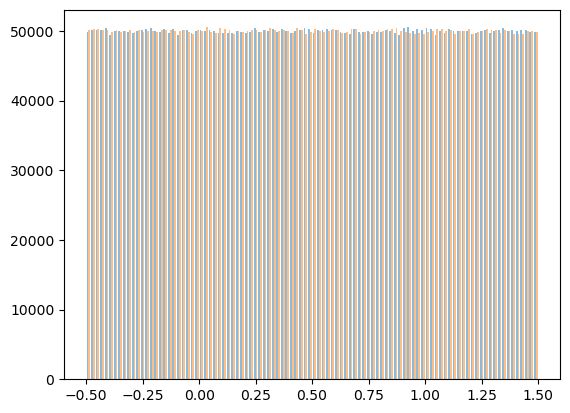

In [4]:
import matplotlib.pyplot as plt

plt.hist(df, bins = 100, alpha=0.5); #added more bins for better idea of variation

df.describe()


In [ ]:

class CircleData:
    def __init__ (self, x, y):
        self.x = x
        self.y = y

thou = CircleData(x[999], y[999])
print(f'Coordinate Pair: ({thou.x}, {thou.y})') #printing the 1000th pair of x and y values

Coordinate Pair: (-0.04718587534338958, 1.0223849131983718)


In [ ]:
import scipy.stats as stats
from scipy.integrate import tplquad # three variable integration
import numpy as np

v = stats.uniform(loc = 0, scale = 4)
h = v.rvs(9999999) # all nines so that it splits into three arrays evenly
u = h.reshape(-1, 3)

x = u[:, 0] 
y = u[:, 1] 
z = u[:, 2] # now we have three arrays, x, y, and z. this is labelling

#using the function x**2 + y**2 + z**2 = 1 (sphere equation)
def g(x, y, z):
    return 1 if x**2 + y**2 + z**2 <= 1 else 0 #now checking if the point is inside the sphere
def sphere_integral_pi():
    result, error = tplquad(g, -1, 1, lambda x,: -np.sqrt(1 - x**2), lambda x: np.sqrt(1 - x**2), 
                            lambda x, y: -np.sqrt(1 - x**2 - y**2), lambda x, y: np.sqrt(1 - x**2 - y**2)) #the third and fourth lambdas are for z
    
    # the above code returns 4/3 * pi, which is the basic volume of a sphere
    pi = result / (4/3) # dividing by 4/3 
    return pi, error
sphere_integral_pi()

(3.1415926535897976, 2.000470900043183e-09)

In [18]:
import numpy as np
import pandas as pd

df_sphere = pd.DataFrame({'x': x, 'y': y, 'z' : z}) 

avg_x = np.mean(df_sphere['x']) #mean of x
avg_y = np.mean(df_sphere['y']) 
avg_z = np.mean(df_sphere['z'])


ss_x = np.sum((df_sphere['x']-avg_x)**2) 
ss_y = np.sum((df_sphere['y']-avg_y)**2) 
ss_z = np.sum((df_sphere['z']-avg_z)**2) 

print(f'{ss_x}')
print(' ') 
print(f'{ss_y}')
print(' ')
print(f'{ss_z}') 


4442522.51588808
 
4442803.532000586
 
4446415.896460082


In [19]:
class SphereData:
    def __init__ (self, x, y, z):
        self.x = x
        self.y = y
        self.z = z